In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Load the dataset

In [2]:
data= pd.read_excel("World_development_mesurement.xlsx")
data.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [3]:
data.shape

(2704, 25)

In [4]:
data.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [6]:
data.describe()

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,Health Exp % GDP,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban
count,2585.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2395.000000,1416.000000,2444.000000,2531.000000,1880.000000,2568.000000,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000
mean,0.022715,1.423071e+05,39.999418,94.875676,7.723684e+04,0.064170,302.068503,0.032813,0.239747,0.148103,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953
std,0.011338,6.159288e+05,57.318588,54.791906,2.599239e+05,0.026325,273.299686,0.029968,0.260132,0.171829,10.708262,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897
min,0.007000,7.000000e+00,1.000000,1.000000,8.000000e+00,0.008000,12.000000,0.002000,0.000000,0.005000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000
25%,0.013000,1.360000e+03,13.000000,48.000000,3.737000e+03,0.046000,156.000000,0.009000,0.000000,0.080000,64.000000,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000
50%,0.020000,8.529000e+03,26.000000,94.000000,1.433800e+04,0.061000,239.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000
75%,0.031000,5.910800e+04,45.000000,142.000000,4.185200e+04,0.079000,344.750000,0.053000,0.400000,0.173000,79.000000,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000
max,0.053000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.225000,2600.000000,0.141000,1.000000,4.965000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000


#### EDA

#### Checking for duplicates

In [7]:
data[data.duplicated()]

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound


In [8]:
#### Removing this column because it consists all ones
data.drop(['Number of Records'],inplace=True,axis=1)

#### Checking null Values

In [9]:
data.isna().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

#### Filling Null Values

In [10]:
birth_rate_mean=data['Birth Rate'].mean()

In [11]:
## this line is to remove '%'
data['Business Tax Rate'] = data['Business Tax Rate'].str.rstrip('%')

In [12]:
## This line coverts the data into float so it will handle null values automatically
data['Business Tax Rate'] = pd.to_numeric(data['Business Tax Rate'], errors='coerce')

In [13]:
## Here i am using median instead of mean because Because tax rates can have outliers median is more robust 
business_tax_rate_median=data['Business Tax Rate'].median()

In [14]:
co2_emissions_median=data['CO2 Emissions'].median()

In [15]:
#### Removing this column because it has many null values
data.drop(['Ease of Business'],axis=1,inplace=True)

In [16]:
data.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Energy Usage', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14',
       'Population 15-64', 'Population 65+', 'Population Total',
       'Population Urban', 'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [17]:
Energy_Usage_median=data['Energy Usage'].median()

In [18]:
cols_to_numeric = [
    'Health Exp % GDP', 'Hours to do Tax',
    'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
    'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
    'Population 0-14', 'Population 15-64', 'Population 65+',
    'Population Urban', 'Energy Usage'
]

for col in cols_to_numeric:
    data[col] = pd.to_numeric(data[col], errors='coerce')


In [19]:
data['Health Exp % GDP'].median()
data['Hours to do Tax'].median()
data['Infant Mortality Rate'].median()
data['Internet Usage'].median()
data['Lending Interest'].mean()  # mean is fine here
data['Life Expectancy Female'].median()
data['Life Expectancy Male'].median()
data['Mobile Phone Usage'].median()
data['Population 0-14'].median()
data['Population 15-64'].median()
data['Population 65+'].median()
data['Population Urban'].median()
data['Energy Usage'].median()

14338.0

In [20]:
currency_columns = ['GDP', 'Health Exp/Capita', 'Tourism Inbound', 'Tourism Outbound']

# Clean dollar signs and commas, then convert to numeric
for col in currency_columns:
    data[col] = data[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
    data[col] = pd.to_numeric(data[col], errors='coerce')


In [21]:
# Step 1: Remove % symbol and strip any spaces
data['Health Exp % GDP'] = data['Health Exp % GDP'].astype(str).str.replace('%', '', regex=False).str.strip()

# Step 2: Convert to numeric
data['Health Exp % GDP'] = pd.to_numeric(data['Health Exp % GDP'], errors='coerce')


In [22]:
# List of columns to clean and convert
percent_columns = ['Health Exp % GDP', 'Business Tax Rate', 'Population Urban']

for col in percent_columns:
    data[col] = data[col].astype(str).str.replace('%', '', regex=False).str.strip()
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [23]:
data.fillna(data.median(numeric_only=True), inplace=True)

In [24]:
# Columns with $ and commas
currency_columns = ['GDP', 'Health Exp/Capita', 'Tourism Inbound', 'Tourism Outbound']

for col in currency_columns:
    data[col] = data[col].astype(str)  # Ensure string
    data[col] = data[col].str.replace('$', '', regex=False)
    data[col] = data[col].str.replace(',', '', regex=False)
    data[col] = pd.to_numeric(data[col], errors='coerce') 

In [25]:
data.fillna({
    'Birth Rate': data['Birth Rate'].median(),
    'Business Tax Rate': data['Business Tax Rate'].median(),
    'CO2 Emissions': data['CO2 Emissions'].median(),
    'Days to Start Business': data['Days to Start Business'].median(),
    'Energy Usage': data['Energy Usage'].median(),
    'GDP': data['GDP'].median(),
    'Health Exp % GDP': data['Health Exp % GDP'].median(),
    'Health Exp/Capita': data['Health Exp/Capita'].median(),
    'Hours to do Tax': data['Hours to do Tax'].median(),
    'Infant Mortality Rate': data['Infant Mortality Rate'].median(),
    'Internet Usage': data['Internet Usage'].median(),
    'Lending Interest': data['Lending Interest'].mean(),  # mean used here
    'Life Expectancy Female': data['Life Expectancy Female'].median(),
    'Life Expectancy Male': data['Life Expectancy Male'].median(),
    'Mobile Phone Usage': data['Mobile Phone Usage'].median(),
    'Population 0-14': data['Population 0-14'].median(),
    'Population 15-64': data['Population 15-64'].median(),
    'Population 65+': data['Population 65+'].median(),
    'Population Urban': data['Population Urban'].median(),
    'Tourism Inbound': data['Tourism Inbound'].median(),
    'Tourism Outbound': data['Tourism Outbound'].median()
}, inplace=True)


In [26]:
data.isna().sum()

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2704 non-null   float64
 1   Business Tax Rate       2704 non-null   float64
 2   CO2 Emissions           2704 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  2704 non-null   float64
 5   Energy Usage            2704 non-null   float64
 6   GDP                     2704 non-null   float64
 7   Health Exp % GDP        2704 non-null   float64
 8   Health Exp/Capita       2704 non-null   float64
 9   Hours to do Tax         2704 non-null   float64
 10  Infant Mortality Rate   2704 non-null   float64
 11  Internet Usage          2704 non-null   float64
 12  Lending Interest        2704 non-null   float64
 13  Life Expectancy Female  2704 non-null   float64
 14  Life Expectancy Male    2704 non-null   

In [28]:
data.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,41.0,87931.0,Algeria,26.0,26998.0,5.479006e+10,0.035,60.0,239.0,...,71.0,67.0,0.0,0.342,0.619,0.039,31719449,0.599,102000000.0,193000000.0
1,0.050,41.0,9542.0,Angola,26.0,7499.0,9.129595e+09,0.034,22.0,239.0,...,47.0,44.0,0.0,0.476,0.499,0.025,13924930,0.324,34000000.0,146000000.0
2,0.043,41.0,1617.0,Benin,26.0,1983.0,2.359122e+09,0.043,15.0,239.0,...,57.0,53.0,0.0,0.454,0.517,0.029,6949366,0.383,77000000.0,50000000.0
3,0.027,41.0,4276.0,Botswana,26.0,1836.0,5.788312e+09,0.047,152.0,239.0,...,52.0,49.0,0.1,0.383,0.587,0.029,1755375,0.532,227000000.0,209000000.0
4,0.046,41.0,1041.0,Burkina Faso,26.0,14338.0,2.610959e+09,0.051,12.0,239.0,...,52.0,49.0,0.0,0.468,0.505,0.028,11607944,0.178,23000000.0,30000000.0


#### Visualization

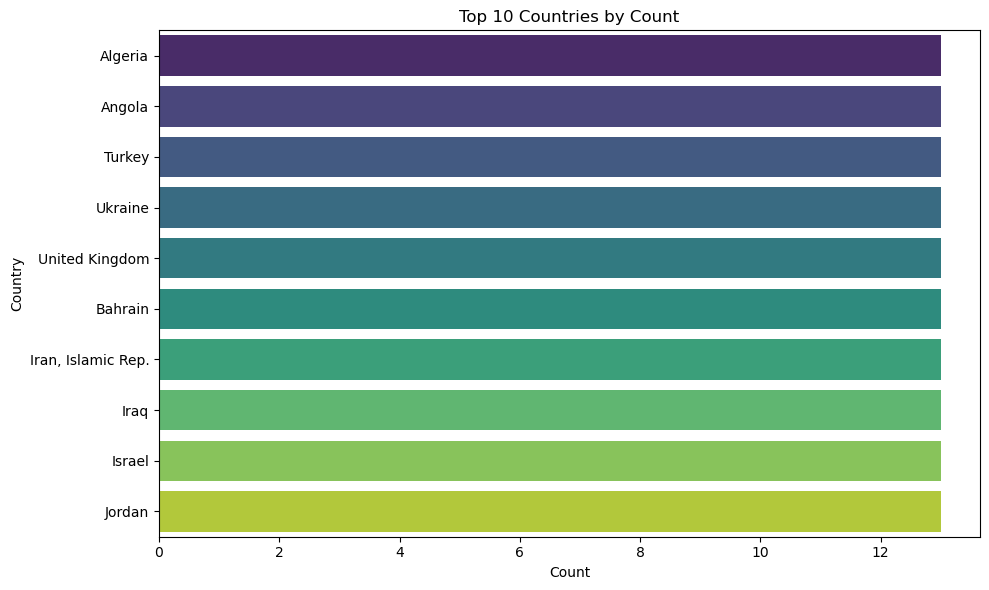

In [29]:
top_countries = data['Country'].value_counts().nlargest(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [30]:
num_columns=data.select_dtypes(['number'])
num_columns

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,...,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,41.0,87931.0,26.0,26998.0,5.479006e+10,0.035,60.0,239.0,0.034,...,71.0,67.0,0.0,0.3420,0.6190,0.039,31719449,0.599,1.020000e+08,1.930000e+08
1,0.050,41.0,9542.0,26.0,7499.0,9.129595e+09,0.034,22.0,239.0,0.128,...,47.0,44.0,0.0,0.4760,0.4990,0.025,13924930,0.324,3.400000e+07,1.460000e+08
2,0.043,41.0,1617.0,26.0,1983.0,2.359122e+09,0.043,15.0,239.0,0.090,...,57.0,53.0,0.0,0.4540,0.5170,0.029,6949366,0.383,7.700000e+07,5.000000e+07
3,0.027,41.0,4276.0,26.0,1836.0,5.788312e+09,0.047,152.0,239.0,0.054,...,52.0,49.0,0.1,0.3830,0.5870,0.029,1755375,0.532,2.270000e+08,2.090000e+08
4,0.046,41.0,1041.0,26.0,14338.0,2.610959e+09,0.051,12.0,239.0,0.096,...,52.0,49.0,0.0,0.4680,0.5050,0.028,11607944,0.178,2.300000e+07,3.000000e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,0.020,41.0,8529.0,26.0,14338.0,1.507975e+10,0.061,193.0,239.0,0.020,...,75.0,69.0,0.5,0.2995,0.6425,0.052,32427,0.911,6.885000e+08,4.560000e+08
2700,0.013,46.4,8529.0,5.0,2132446.0,1.624460e+13,0.179,8895.0,175.0,0.006,...,81.0,76.0,1.0,0.1960,0.6670,0.136,313873685,0.811,2.000920e+11,1.265730e+11
2701,0.015,41.9,8529.0,7.0,14338.0,5.000435e+10,0.089,1308.0,310.0,0.010,...,80.0,74.0,1.5,0.2200,0.6390,0.140,3395253,0.948,2.222000e+09,1.028000e+09
2702,0.020,61.9,8529.0,144.0,14338.0,3.812862e+11,0.046,593.0,792.0,0.013,...,78.0,72.0,1.0,0.2880,0.6520,0.060,29954782,0.889,9.040000e+08,3.202000e+09


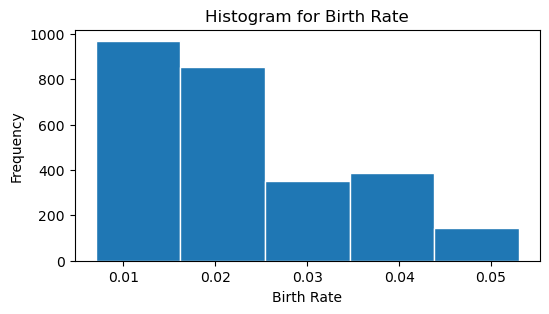

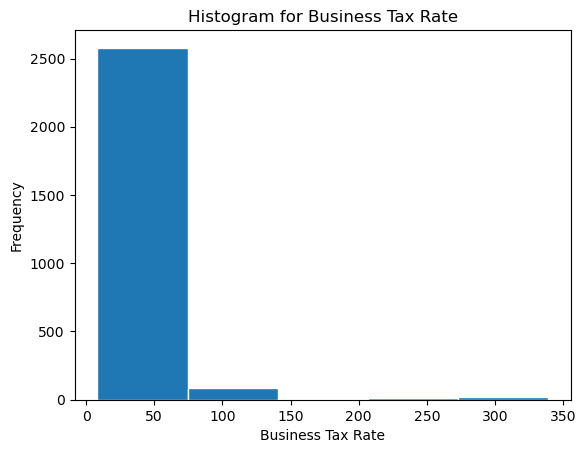

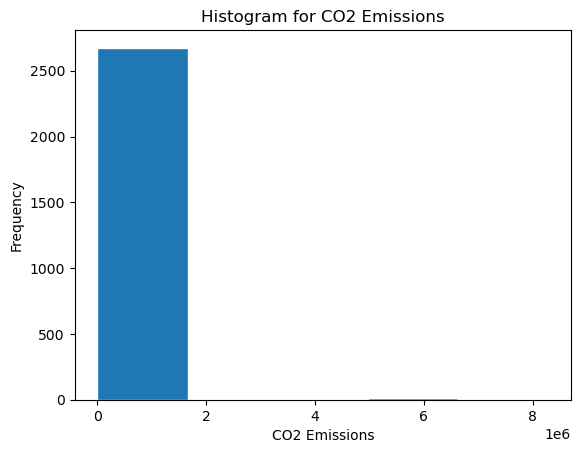

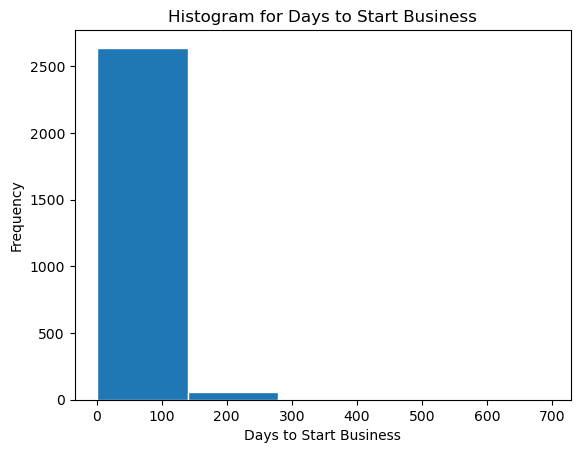

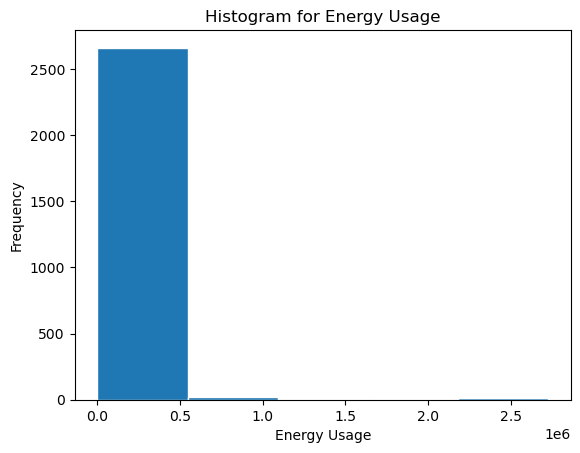

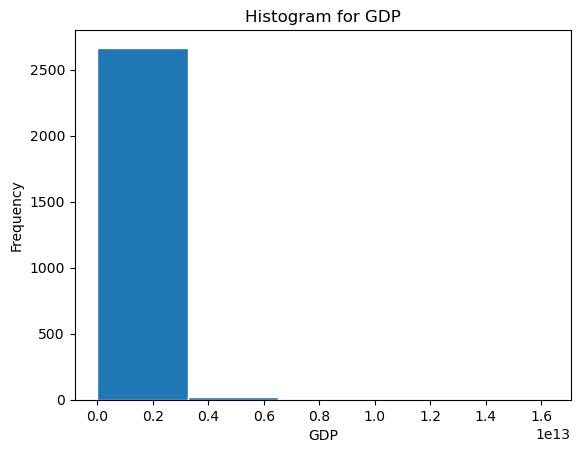

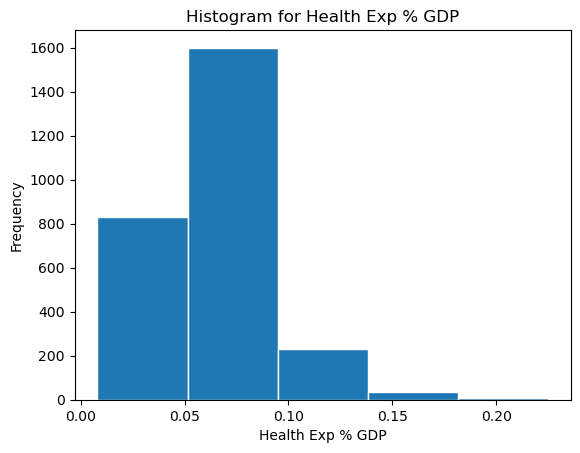

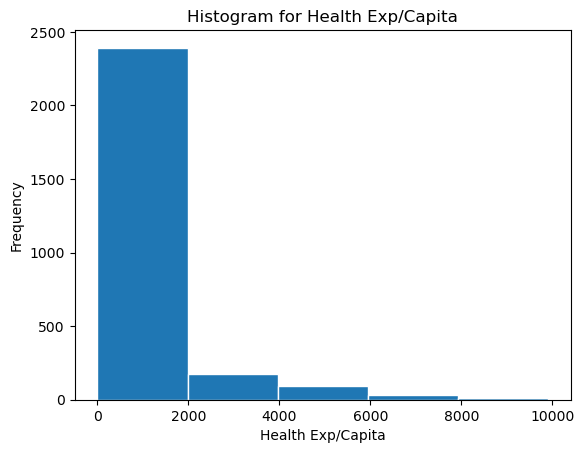

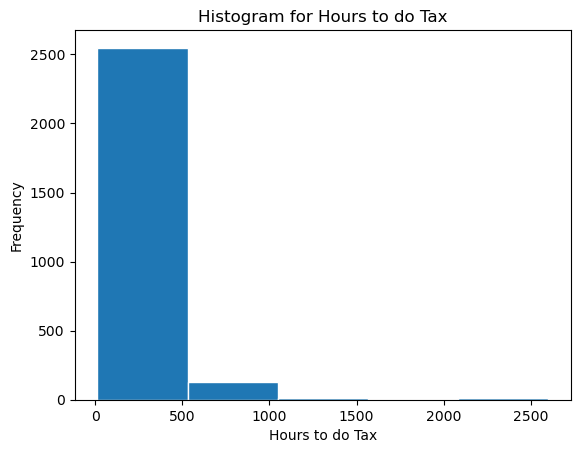

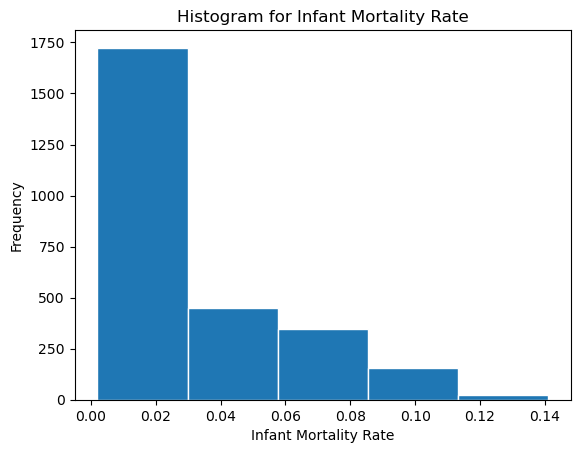

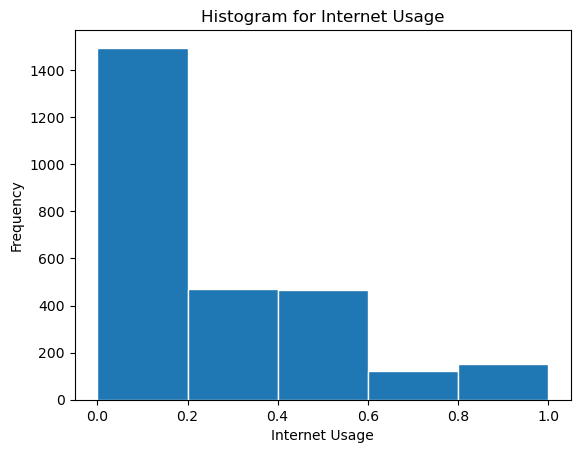

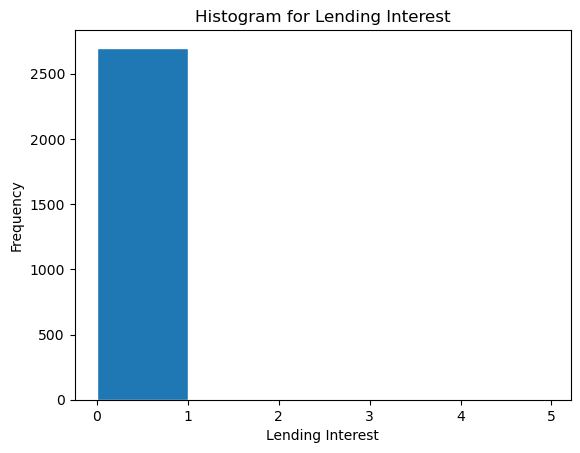

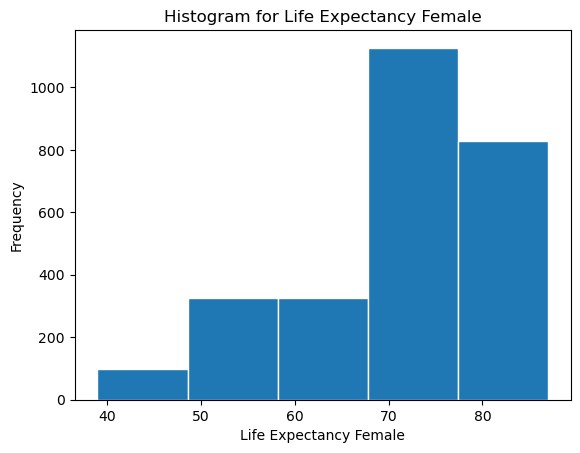

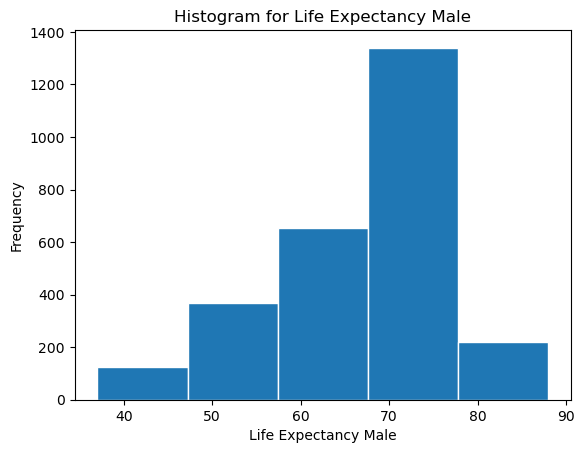

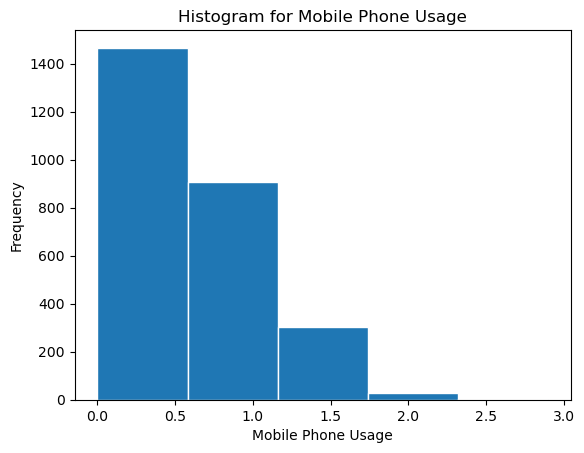

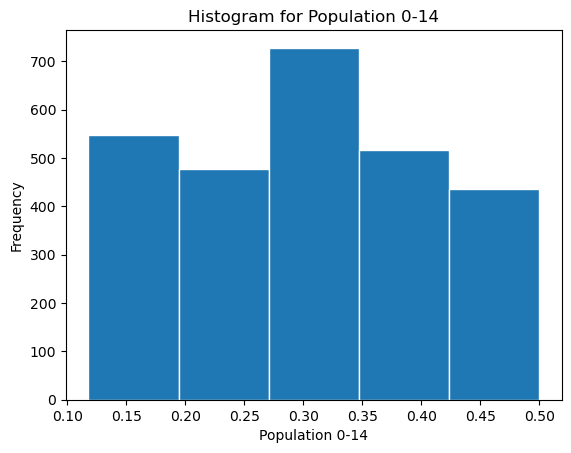

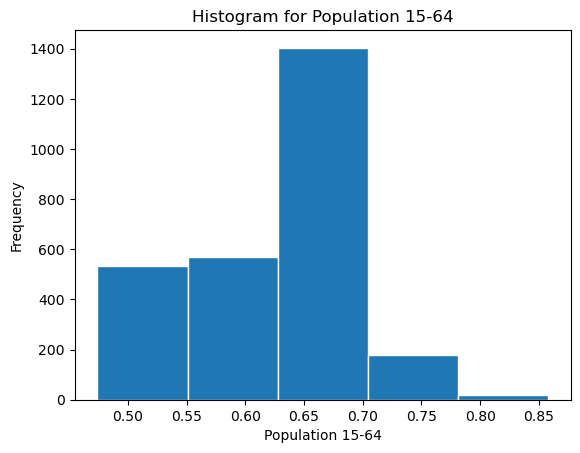

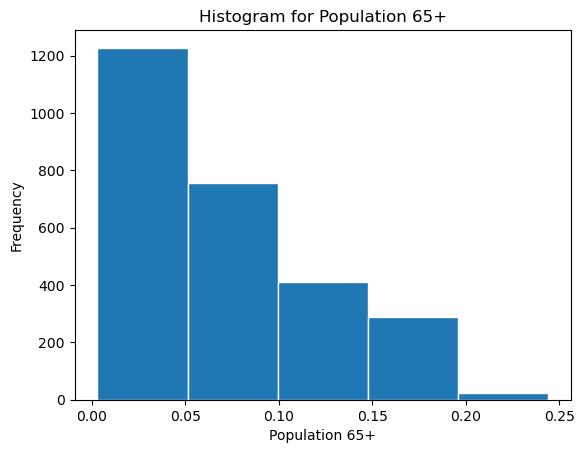

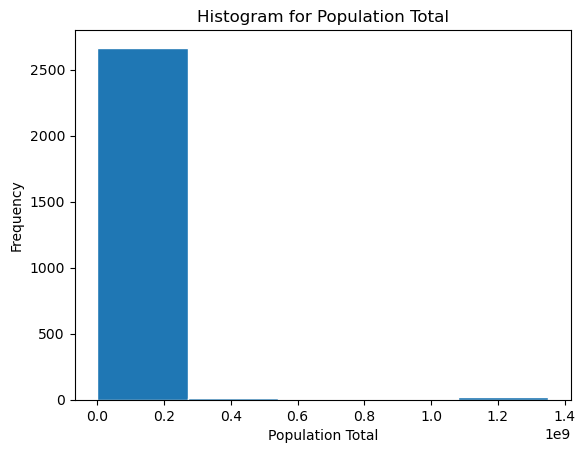

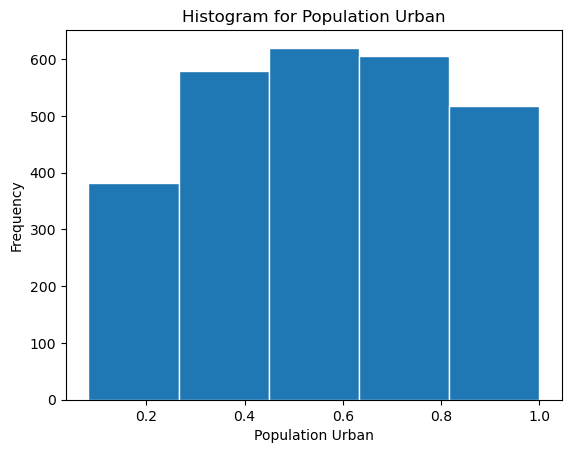

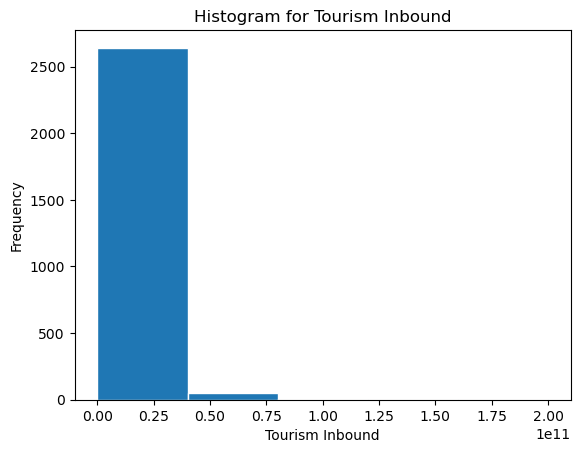

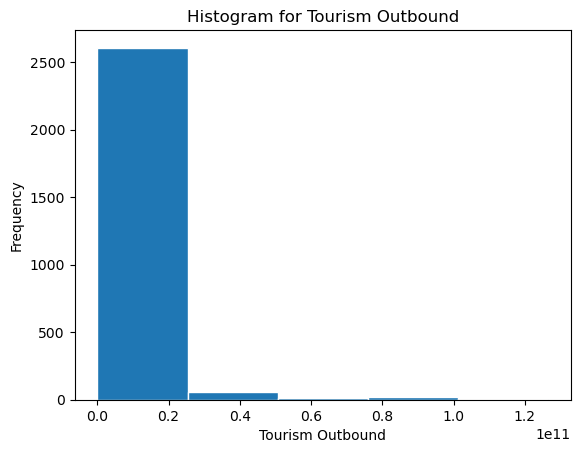

In [31]:
plt.figure(figsize=(6,3))
for cols in num_columns:
    plt.hist(data[cols],bins=5,edgecolor='white')
    plt.xlabel(cols)
    plt.ylabel('Frequency')
    plt.title(f'Histogram for {cols}')
    plt.show()

#### Scaling the data

In [32]:
## Here I am Applying MinMax normalization for this selected high-range numerical features to bring them to a common scale for effective clustering
columns_to_normalize = [
    'Business_Tax_Rate',
    'CO2_Emissions',
    'Days_to_Start_Business',
    'Energy_Usage',
    'GDP',
    'Health_Exp_per_Capita',
    'Hours_to_do_Tax',
    'Lending_Interest',
    'Life_Expectancy_Female',
    'Life_Expectancy_Male',
    'Mobile_Phone_Usage',
    'Population_Total',
    'Tourism_Inbound',
    'Tourism_Outbound'
]

In [33]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('+', 'plus').str.replace('-', '_').str.replace('%', 'percentage')

In [34]:
columns_to_normalize = [
    'birth_rate', 'business_tax_rate', 'co2_emissions', 'days_to_start_business',
    'energy_usage', 'gdp', 'health_exp_percentage_gdp', 'health_exp/capita',
    'hours_to_do_tax', 'infant_mortality_rate', 'internet_usage', 'lending_interest',
    'life_expectancy_female', 'life_expectancy_male', 'mobile_phone_usage',
    'population_0_14', 'population_15_64', 'population_65plus',
    'population_urban', 'tourism_inbound', 'tourism_outbound'
]

#### RobusterScaler is designed specifially to handle outliers by scaling based on median and IQR

In [35]:
from sklearn.preprocessing import RobustScaler

In [36]:
from sklearn.preprocessing import RobustScaler

columns_to_normalize = ['gdp', 'co2_emissions', 'health_exp/capita', 
                        'business_tax_rate', 'energy_usage', 'birth_rate']

for cols in columns_to_normalize:
    scaler = RobustScaler()
    data[cols] = scaler.fit_transform(data[[cols]])


In [37]:
data.describe()

,birth_rate,business_tax_rate,co2_emissions,days_to_start_business,energy_usage,gdp,health_exp_percentage_gdp,health_exp/capita,hours_to_do_tax,infant_mortality_rate,...,life_expectancy_female,life_expectancy_male,mobile_phone_usage,population_0_14,population_15_64,population_65plus,population_total,population_urban,tourism_inbound,tourism_outbound
count,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,...,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2.704000e+03,2704.000000,2.704000e+03,2.704000e+03
mean,0.152671,2.206653,2.607131,34.894601,2.657426,2.640298,0.063807,1.092493,272.026997,0.031581,...,71.352441,66.589497,0.573299,0.302762,0.625029,0.071718,3.145729e+07,0.562924,4.360806e+09,3.985061e+09
std,0.652942,15.773639,13.607987,46.177780,13.648632,12.509965,0.024795,2.838563,200.233912,0.028739,...,10.469114,9.167741,0.460136,0.102152,0.066967,0.047844,1.242894e+08,0.244712,1.295591e+10,1.216499e+10
min,-0.764706,-17.263158,-0.211333,1.000000,-0.917135,-0.172795,0.008000,-0.387228,12.000000,0.002000,...,39.000000,37.000000,0.000000,0.118000,0.474000,0.003000,1.887600e+04,0.082000,7.000000e+05,2.000000e+05
25%,-0.411765,-0.315789,-0.156032,20.000000,-0.415127,-0.126185,0.048000,-0.273695,229.500000,0.010000,...,65.000000,61.000000,0.200000,0.210000,0.565000,0.034000,8.783360e+05,0.357750,1.860000e+08,1.470000e+08
50%,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000,0.061000,0.000000,239.000000,0.020000,...,75.000000,69.000000,0.500000,0.299500,0.642500,0.052000,5.800324e+06,0.560000,6.885000e+08,4.560000e+08
75%,0.588235,0.684211,0.843968,34.250000,0.584873,0.873815,0.076000,0.726305,256.000000,0.049000,...,79.000000,73.000000,0.900000,0.395000,0.673000,0.105000,2.014089e+07,0.763000,2.648000e+09,1.711500e+09
max,1.941176,156.894737,205.291085,694.000000,173.659739,186.751193,0.225000,19.695895,2600.000000,0.141000,...,87.000000,88.000000,2.900000,0.500000,0.858000,0.244000,1.350695e+09,1.000000,2.000920e+11,1.265730e+11


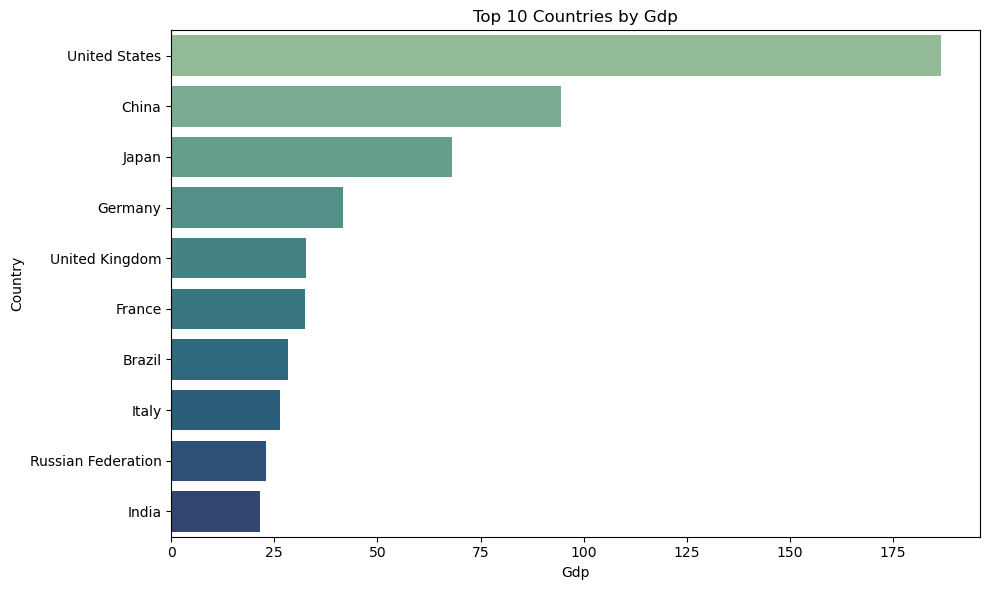

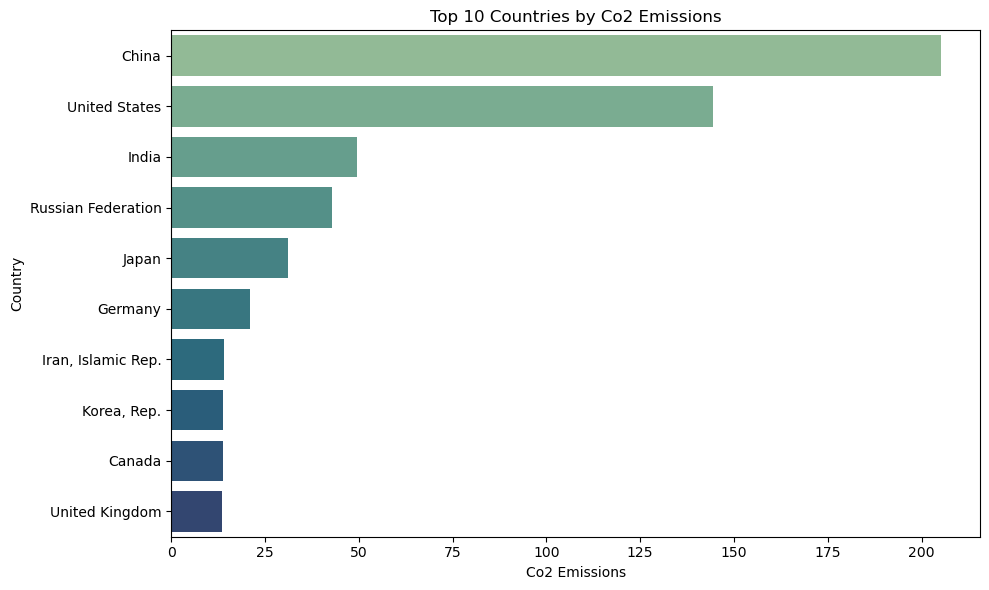

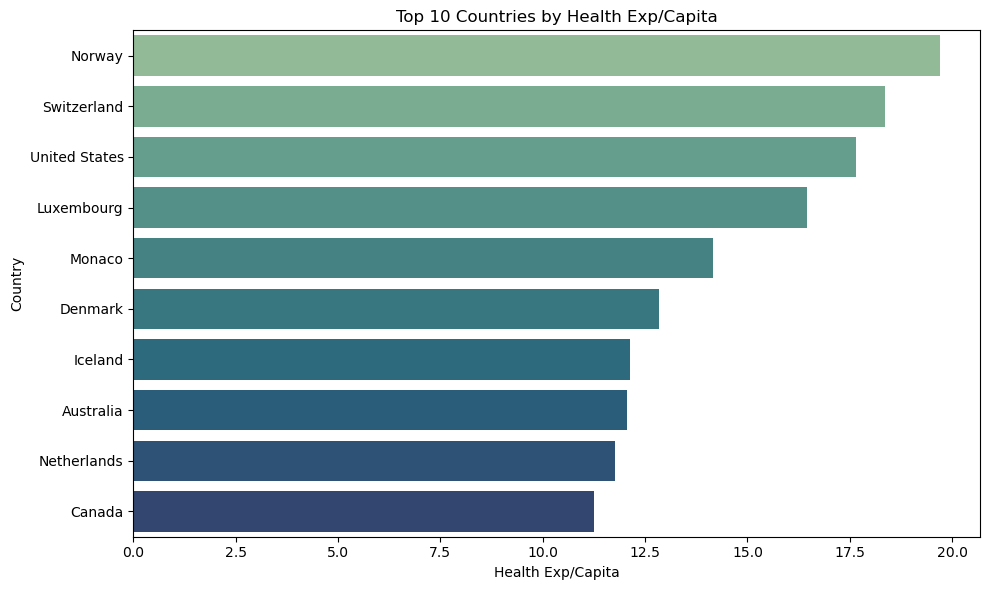

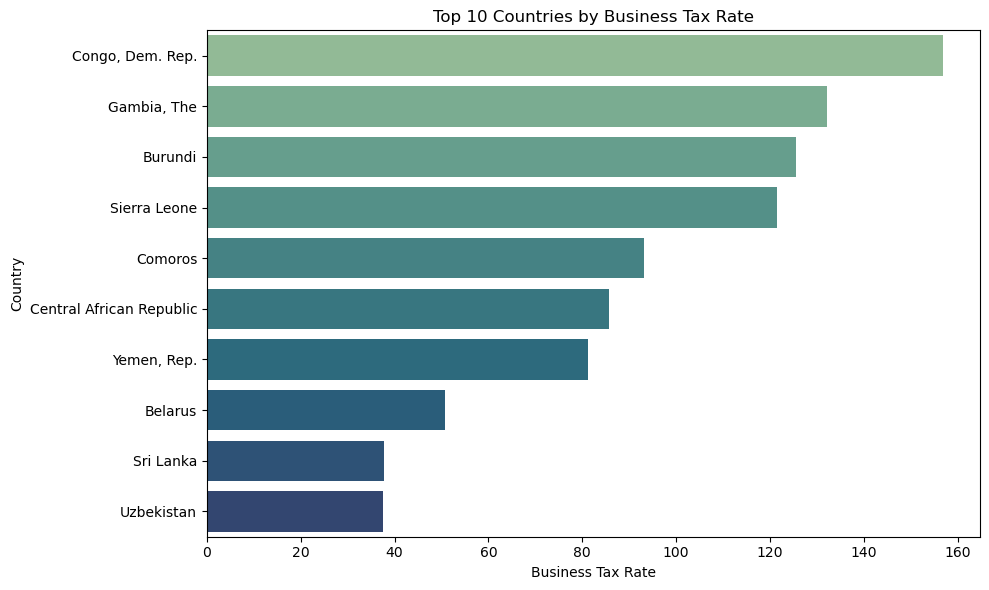

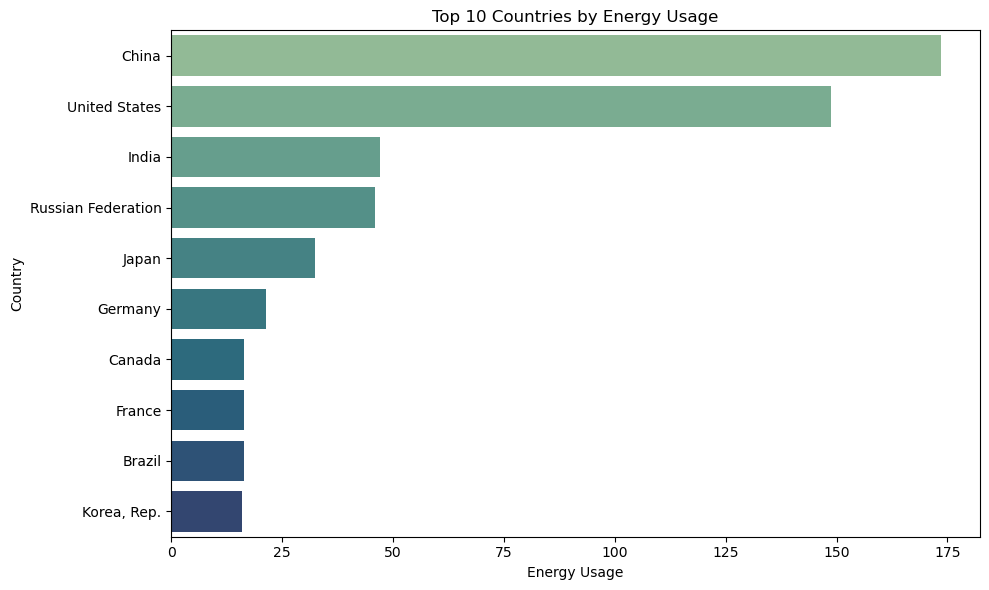

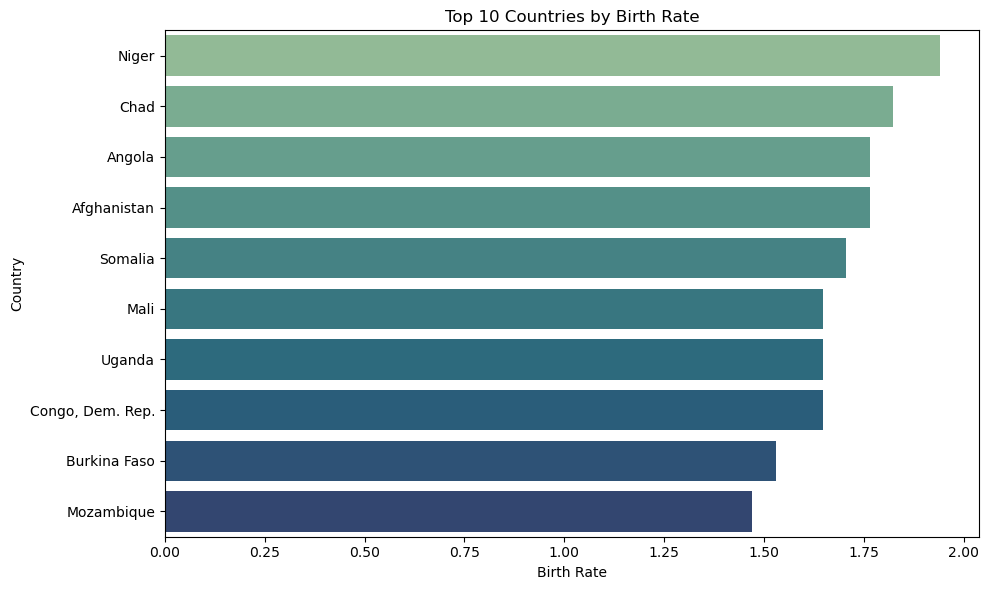

In [38]:
parameters = ['gdp', 'co2_emissions', 'health_exp/capita', 
              'business_tax_rate', 'energy_usage', 'birth_rate']

for param in parameters:
    top_countries = data[['country', param]].dropna().sort_values(by=param, ascending=False).drop_duplicates(subset='country').head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=param, y='country', data=top_countries, palette='crest')
    plt.title(f'Top 10 Countries by {param.replace("_", " ").title()}')
    plt.xlabel(param.replace("_", " ").title())
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()

In [39]:
#### Here i am copying original data because here i dont want country column it is not effective in clustering

In [40]:
data1=data.copy()

In [41]:
data1.drop('country', axis=1, inplace=True)

In [42]:
correlation=data1.corr()
correlation


,birth_rate,business_tax_rate,co2_emissions,days_to_start_business,energy_usage,gdp,health_exp_percentage_gdp,health_exp/capita,hours_to_do_tax,infant_mortality_rate,...,life_expectancy_female,life_expectancy_male,mobile_phone_usage,population_0_14,population_15_64,population_65plus,population_total,population_urban,tourism_inbound,tourism_outbound
birth_rate,1.000000,0.210435,-0.148665,0.142392,-0.159230,-0.184839,-0.203536,-0.411804,0.055880,0.866444,...,-0.864448,-0.821947,-0.536971,0.941822,-0.906371,-0.737706,-0.054973,-0.592360,-0.270296,-0.275113
business_tax_rate,0.210435,1.000000,0.025192,0.022330,0.027167,0.016925,0.044159,-0.073806,0.157252,0.222757,...,-0.202413,-0.220166,-0.106278,0.158522,-0.188364,-0.073951,0.053004,-0.093333,0.000344,-0.004125
co2_emissions,-0.148665,0.025192,1.000000,-0.027550,0.908944,0.693480,0.144582,0.207046,0.066940,-0.107813,...,0.106685,0.112328,0.016765,-0.169931,0.158759,0.142830,0.655298,0.073803,0.591023,0.561877
days_to_start_business,0.142392,0.022330,-0.027550,1.000000,-0.037432,-0.058190,-0.101871,-0.142882,0.151162,0.149225,...,-0.162751,-0.172542,-0.111373,0.163997,-0.136081,-0.157461,0.011373,-0.083134,-0.095646,-0.091924
energy_usage,-0.159230,0.027167,0.908944,-0.037432,1.000000,0.852598,0.204383,0.283808,0.069807,-0.118395,...,0.121721,0.127748,0.044601,-0.187804,0.162603,0.175438,0.653808,0.093780,0.738068,0.696566
gdp,-0.184839,0.016925,0.693480,-0.058190,0.852598,1.000000,0.330315,0.451191,0.040062,-0.167284,...,0.183728,0.195792,0.128016,-0.228162,0.150629,0.278436,0.381322,0.164949,0.880682,0.858337
health_exp_percentage_gdp,-0.203536,0.044159,0.144582,-0.101871,0.204383,0.330315,1.000000,0.445972,-0.040249,-0.157454,...,0.183905,0.193580,0.163672,-0.262464,0.081764,0.445454,-0.050497,0.178169,0.368690,0.353248
health_exp/capita,-0.411804,-0.073806,0.207046,-0.142882,0.283808,0.451191,0.445972,1.000000,-0.153628,-0.426319,...,0.440373,0.477241,0.418276,-0.478777,0.320361,0.573116,0.005577,0.438859,0.524197,0.553759
hours_to_do_tax,0.055880,0.157252,0.066940,0.151162,0.069807,0.040062,-0.040249,-0.153628,1.000000,0.082720,...,-0.076614,-0.108671,-0.005034,0.048673,-0.059124,-0.019068,0.123811,-0.003348,-0.035452,-0.016411
infant_mortality_rate,0.866444,0.222757,-0.107813,0.149225,-0.118395,-0.167284,-0.157454,-0.426319,0.082720,1.000000,...,-0.922481,-0.900726,-0.563304,0.808403,-0.790545,-0.614331,0.017421,-0.594938,-0.244072,-0.247918


<Axes: >

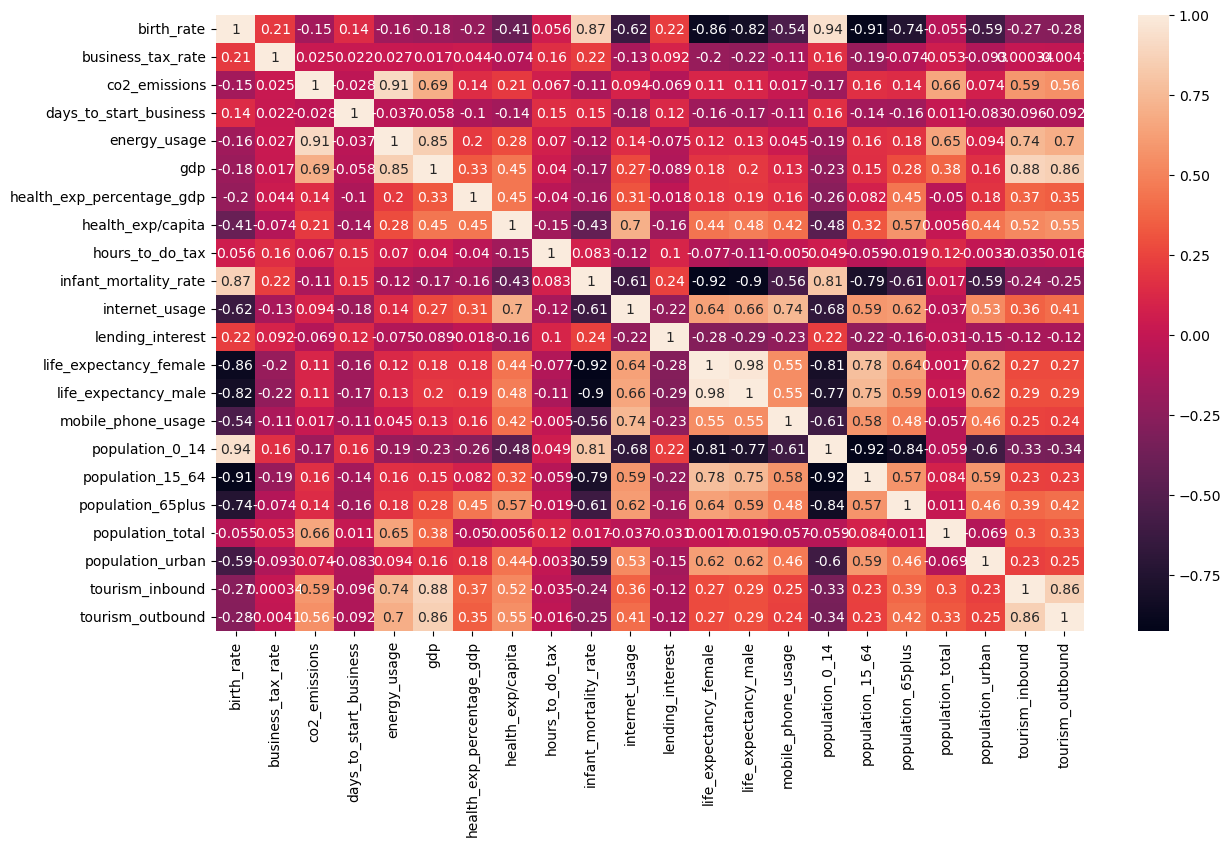

In [43]:
plt.figure(figsize=(14,8))
sns.heatmap(correlation,annot=True)

In [44]:
columns_to_drop = [
    'infant_mortality_rate',
    'life_expectancy_male',
    'population_0_14',
    'co2_emissions',
    'tourism_inbound',
    'tourism_outbound'
]

data1.drop(columns=columns_to_drop, inplace=True)

In [45]:
data1.head()

,birth_rate,business_tax_rate,days_to_start_business,energy_usage,gdp,health_exp_percentage_gdp,health_exp/capita,hours_to_do_tax,internet_usage,lending_interest,life_expectancy_female,mobile_phone_usage,population_15_64,population_65plus,population_total,population_urban
0,0.000000,0.0,26.0,0.810253,0.456942,0.035,-0.269640,239.0,0.0,0.100,71.0,0.0,0.619,0.039,31719449,0.599
1,1.764706,0.0,26.0,-0.437703,-0.068468,0.034,-0.346680,239.0,0.0,1.032,47.0,0.0,0.499,0.025,13924930,0.324
2,1.352941,0.0,26.0,-0.790733,-0.146375,0.043,-0.360872,239.0,0.0,0.120,57.0,0.0,0.517,0.029,6949366,0.383
3,0.411765,0.0,26.0,-0.800141,-0.106916,0.047,-0.083122,239.0,0.0,0.155,52.0,0.1,0.587,0.029,1755375,0.532
4,1.529412,0.0,26.0,0.000000,-0.143477,0.051,-0.366954,239.0,0.0,0.120,52.0,0.0,0.505,0.028,11607944,0.178


#### PCA

In [46]:
from sklearn.decomposition import PCA

#### Getting the principle components

In [47]:
pca=PCA()
pcomps=pca.fit_transform(data1)
pcomps

array([[ 2.62155105e+05, -3.34026850e+01, -7.55516002e+00, ...,
        -2.52323431e-02, -1.51131457e-02, -2.07439211e-01],
       [-1.75323639e+07, -2.97513385e+01, -6.71900406e+00, ...,
        -6.90560299e-04, -3.41589639e-02,  3.31769497e-01],
       [-2.45079279e+07, -2.84014014e+01, -7.11999582e+00, ...,
         8.97454645e-03, -1.84679429e-02,  4.17930169e-01],
       ...,
       [-2.80620409e+07,  4.24524491e+01, -2.96479051e+01, ...,
         6.54408851e-02,  1.57360108e-03,  5.44284086e-02],
       [-1.50251189e+06,  5.23990632e+02,  8.93474454e+01, ...,
        -2.62277212e-02, -6.35061099e-03,  1.97241645e-01],
       [-3.13520189e+07, -2.71465250e+01, -8.14349642e+00, ...,
         7.49420254e-02, -2.65781645e-02, -9.11344429e-02]])

In [48]:
ratio=pca.explained_variance_ratio_
ratio

array([1.00000000e+00, 2.55938369e-12, 1.34956238e-13, 1.63146730e-14,
       1.47543364e-14, 6.13849149e-15, 1.07163523e-15, 3.10448589e-16,
       9.63093417e-18, 2.17399290e-18, 1.20482086e-18, 9.03128670e-19,
       1.20840131e-19, 6.78874580e-20, 2.43885938e-20, 0.00000000e+00])

In [49]:
vars = np.round(np.cumsum(ratio)*100,1)
vars

array([100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100.])

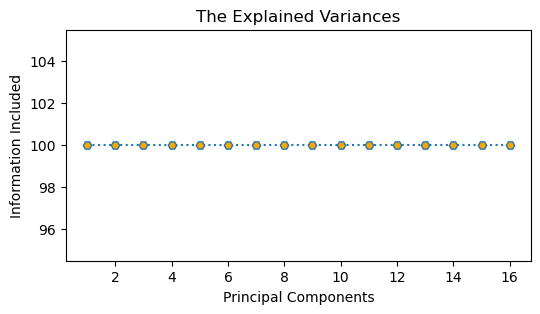

In [50]:
plt.figure(figsize=(6,3))
plt.plot(range(1,17),vars, linestyle='dotted',
         marker='H',markerfacecolor='orange'
        )
plt.title('The Explained Variances')
plt.xlabel('Principal Components')
plt.ylabel('Information Included')
plt.show()

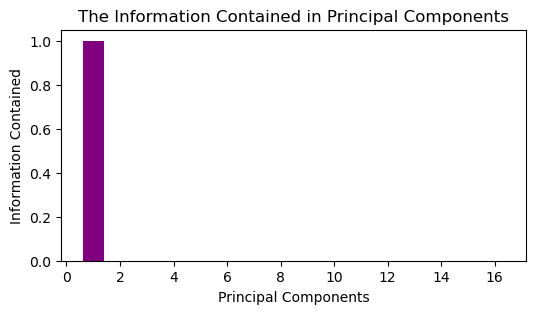

In [51]:
plt.figure(figsize=(6,3))
plt.bar(x= range(1,17),
        height=ratio,
        color='purple'
       )
plt.title('The Information Contained in Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Information Contained')
plt.show()

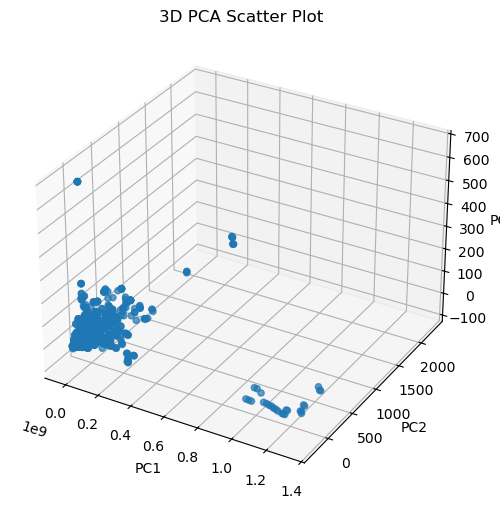

In [52]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pcomps[:, 0], pcomps[:, 1], pcomps[:, 2], alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Scatter Plot')
plt.show()

In [53]:
data2 = pd.DataFrame({'PC1':pcomps[:,0], 'PC2':pcomps[:,1],'PC3':pcomps[:,2],'PC4':pcomps[:,3]})
data2

,PC1,PC2,PC3,PC4
0,2.621551e+05,-33.402685,-7.555160,-0.401689
1,-1.753236e+07,-29.751339,-6.719004,5.904484
2,-2.450793e+07,-28.401401,-7.119996,3.242748
3,-2.970192e+07,-27.345357,-6.965251,4.404007
4,-1.984935e+07,-29.310396,-6.922198,4.479500
...,...,...,...,...
2699,-3.142487e+07,-27.098503,-7.845143,-1.826594
2700,2.824164e+08,-154.659253,-30.895357,-66.203593
2701,-2.806204e+07,42.452449,-29.647905,-3.341073
2702,-1.502512e+06,523.990632,89.347445,-1.698049


#### Model Building

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [55]:
sil = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data2)
    sil.append(silhouette_score(data2, labels))

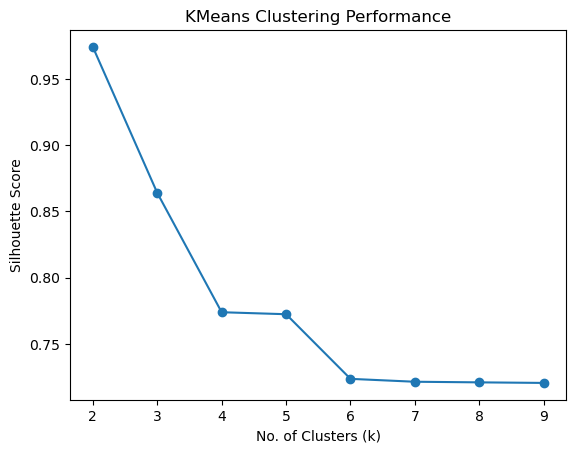

In [56]:
plt.plot(K, sil, marker='o')
plt.xlabel('No. of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('KMeans Clustering Performance')
plt.show()

In [57]:
kmeans = KMeans(n_clusters=3, random_state=42)
data2['Kmeans'] = kmeans.fit_predict(data2)

In [58]:
data1['Kmeans']=kmeans.labels_

In [59]:
kmeans_score = silhouette_score(data2, data2['Kmeans'])
print(f'Silhouette Score (KMeans): {kmeans_score:.4f}')

Silhouette Score (KMeans): 0.8640


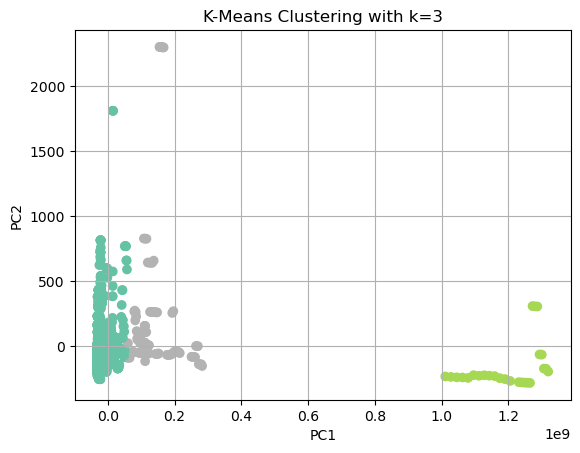

In [60]:
plt.scatter(data2['PC1'], data2['PC2'], c=data2['Kmeans'], cmap='Set2')
plt.title("K-Means Clustering with k=3")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [61]:
from sklearn.manifold import TSNE

In [62]:
tsne = TSNE(n_components=2
           )
tcomps = tsne.fit_transform(data1)

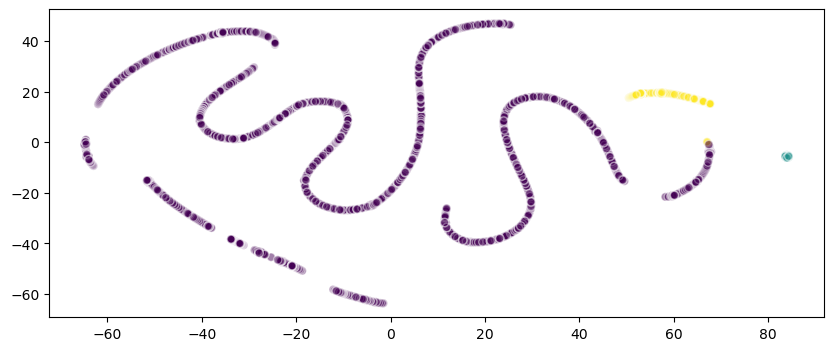

In [63]:
plt.figure(figsize=(10,4))

plt.scatter(tcomps[:,0], tcomps[:,1], 
            cmap='viridis', 
            c=data1['Kmeans'],
            alpha=0.5,
            edgecolors='white'
           )
plt.show()

In [64]:
data1.head()

,birth_rate,business_tax_rate,days_to_start_business,energy_usage,gdp,health_exp_percentage_gdp,health_exp/capita,hours_to_do_tax,internet_usage,lending_interest,life_expectancy_female,mobile_phone_usage,population_15_64,population_65plus,population_total,population_urban,Kmeans
0,0.000000,0.0,26.0,0.810253,0.456942,0.035,-0.269640,239.0,0.0,0.100,71.0,0.0,0.619,0.039,31719449,0.599,0
1,1.764706,0.0,26.0,-0.437703,-0.068468,0.034,-0.346680,239.0,0.0,1.032,47.0,0.0,0.499,0.025,13924930,0.324,0
2,1.352941,0.0,26.0,-0.790733,-0.146375,0.043,-0.360872,239.0,0.0,0.120,57.0,0.0,0.517,0.029,6949366,0.383,0
3,0.411765,0.0,26.0,-0.800141,-0.106916,0.047,-0.083122,239.0,0.0,0.155,52.0,0.1,0.587,0.029,1755375,0.532,0
4,1.529412,0.0,26.0,0.000000,-0.143477,0.051,-0.366954,239.0,0.0,0.120,52.0,0.0,0.505,0.028,11607944,0.178,0


In [65]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

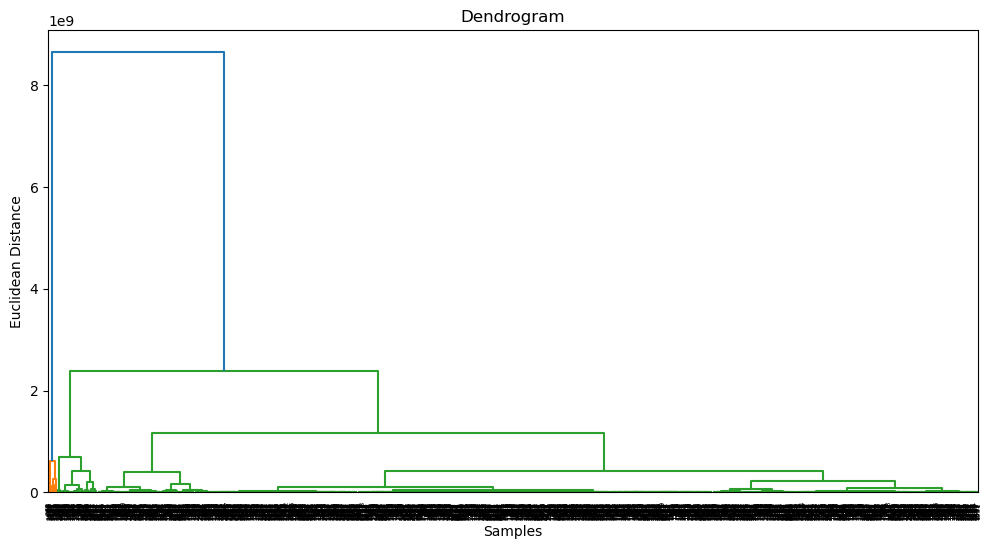

In [66]:
plt.figure(figsize=(12, 6))
linked = linkage(data2, method='ward')  # 'ward' minimizes variance within clusters
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()


In [67]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels = hc.fit_predict(data2)  # use scaled_data, not raw data2

# Add labels to your data
data1['heirarchical'] = labels
data2['heirarchical']=labels

In [68]:
score = silhouette_score(data2, labels)
print(f'Silhouette Score (Hierarchical Clustering): {score:.4f}')

Silhouette Score (Hierarchical Clustering): 0.8660


In [69]:
data2

,PC1,PC2,PC3,PC4,Kmeans,heirarchical
0,2.621551e+05,-33.402685,-7.555160,-0.401689,0,0
1,-1.753236e+07,-29.751339,-6.719004,5.904484,0,0
2,-2.450793e+07,-28.401401,-7.119996,3.242748,0,0
3,-2.970192e+07,-27.345357,-6.965251,4.404007,0,0
4,-1.984935e+07,-29.310396,-6.922198,4.479500,0,0
...,...,...,...,...,...,...
2699,-3.142487e+07,-27.098503,-7.845143,-1.826594,0,0
2700,2.824164e+08,-154.659253,-30.895357,-66.203593,2,2
2701,-2.806204e+07,42.452449,-29.647905,-3.341073,0,0
2702,-1.502512e+06,523.990632,89.347445,-1.698049,0,0


In [70]:
print(data2['Kmeans'].value_counts())
print(data2['heirarchical'].value_counts())

Kmeans
0    2556
2     122
1      26
Name: count, dtype: int64
heirarchical
0    2561
2     117
1      26
Name: count, dtype: int64


In [71]:
# Cluster 0
print("\nCluster 0 Means:")
print(data1[data1['Kmeans'] == 0].mean(numeric_only=True).round(2))
# Cluster 1
print("\nCluster 1 Means:")
print(data1[data1['Kmeans'] == 1].mean(numeric_only=True).round(2))
# Cluster 2
print("\nCluster 2 Means:")
print(data1[data1['Kmeans'] == 2].mean(numeric_only=True).round(2))


Cluster 0 Means:
birth_rate                          0.16
business_tax_rate                   2.17
days_to_start_business             34.54
energy_usage                        0.80
gdp                                 1.23
health_exp_percentage_gdp           0.06
health_exp/capita                   1.05
hours_to_do_tax                   260.05
internet_usage                      0.23
lending_interest                    0.14
life_expectancy_female             71.33
mobile_phone_usage                  0.58
population_15_64                    0.62
population_65plus                   0.07
population_total             12762851.31
population_urban                    0.56
Kmeans                              0.00
heirarchical                        0.00
dtype: float64

Cluster 1 Means:
birth_rate                  -1.400000e-01
business_tax_rate            9.320000e+00
days_to_start_business       3.923000e+01
energy_usage                 7.055000e+01
gdp                          2.678000e+01
h

In [72]:
data1.head()

,birth_rate,business_tax_rate,days_to_start_business,energy_usage,gdp,health_exp_percentage_gdp,health_exp/capita,hours_to_do_tax,internet_usage,lending_interest,life_expectancy_female,mobile_phone_usage,population_15_64,population_65plus,population_total,population_urban,Kmeans,heirarchical
0,0.000000,0.0,26.0,0.810253,0.456942,0.035,-0.269640,239.0,0.0,0.100,71.0,0.0,0.619,0.039,31719449,0.599,0,0
1,1.764706,0.0,26.0,-0.437703,-0.068468,0.034,-0.346680,239.0,0.0,1.032,47.0,0.0,0.499,0.025,13924930,0.324,0,0
2,1.352941,0.0,26.0,-0.790733,-0.146375,0.043,-0.360872,239.0,0.0,0.120,57.0,0.0,0.517,0.029,6949366,0.383,0,0
3,0.411765,0.0,26.0,-0.800141,-0.106916,0.047,-0.083122,239.0,0.0,0.155,52.0,0.1,0.587,0.029,1755375,0.532,0,0
4,1.529412,0.0,26.0,0.000000,-0.143477,0.051,-0.366954,239.0,0.0,0.120,52.0,0.0,0.505,0.028,11607944,0.178,0,0


In [73]:
cluster_labels = {
    0: 'Emerging & Developing',
    1: 'Developed Superpowers',
    2: 'Least Developed'
}

data2['KMeans_Label'] = data2['Kmeans'].map(cluster_labels)

In [74]:
data2.head()

,PC1,PC2,PC3,PC4,Kmeans,heirarchical,KMeans_Label
0,2.621551e+05,-33.402685,-7.555160,-0.401689,0,0,Emerging & Developing
1,-1.753236e+07,-29.751339,-6.719004,5.904484,0,0,Emerging & Developing
2,-2.450793e+07,-28.401401,-7.119996,3.242748,0,0,Emerging & Developing
3,-2.970192e+07,-27.345357,-6.965251,4.404007,0,0,Emerging & Developing
4,-1.984935e+07,-29.310396,-6.922198,4.479500,0,0,Emerging & Developing


#### Model Deployment

In [75]:
features = ['birth_rate', 'business_tax_rate', 'days_to_start_business',
            'energy_usage', 'gdp', 'health_exp_percentage_gdp',
            'health_exp/capita', 'hours_to_do_tax', 'internet_usage',
            'lending_interest', 'life_expectancy_female',
            'mobile_phone_usage', 'population_15_64', 'population_65plus',
            'population_total', 'population_urban']

X = data[features]


In [76]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [77]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

#### Logistic Regression

In [78]:
from sklearn.model_selection import train_test_split

# Features (already scaled)
X = data[features] 

# Target from clustering
y = data2['KMeans_Label']  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts())

X_train shape: (2163, 16)
y_train distribution:
 KMeans_Label
Emerging & Developing    2045
Least Developed            97
Developed Superpowers      21
Name: count, dtype: int64


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [80]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [81]:
y_pred_lr = lr_model.predict(X_train)
lr_accuracy = accuracy_score(y_train, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9953767914932964


In [82]:
y_pred_lr = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9944547134935305


#### SVM

In [83]:
from sklearn.svm import SVC

In [84]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [85]:
y_pred_svm = svm_model.predict(X_train)
svm_accuracy = accuracy_score(y_train, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 1.0


In [86]:
y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 1.0


#### Neural Network

In [87]:
from sklearn.neural_network import MLPClassifier

In [88]:
nn_model = MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42)

In [89]:
y_pred_nn = nn_model.predict(X_train)
nn_accuracy = accuracy_score(y_train, y_pred_nn)
print("Neural Network Accuracy:", nn_accuracy)

Neural Network Accuracy: 0.14331946370781323


In [90]:
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)